# MNIST: CNN Accuracy vs Computational Cost (PyTorch)

This notebook compares a dense neural network and three CNN architectures on MNIST. Students will measure accuracy, parameter counts, model size, and training time to understand the tradeoff between model complexity and performance.

## Lab 6 overview

- **Part 1** runs the four baseline models exactly as provided (3 epochs, Adam, learning rate 0.001).
- **Part 2** adds a new model, `EfficientCNN`.
- **Part 3** checks it against the constraints: test accuracy of at least 99% with at most 100,000 parameters.
- **Part 4** is the results table, the accuracy graph, the parameter graph, and the engineering justification at the end.

Changes to the starting notebook are marked with `# NEW` or `# CHANGED` comments.

In [1]:
# requirements
%pip install torch torchvision pandas matplotlib

In [2]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import pandas as pd
import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)

PyTorch: 2.14.1+cu130


In [3]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset,batch_size=128,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=128,shuffle=False)

#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device = torch.device("cpu")
print("Device:", device)

Device: cpu


In [4]:
class DenseNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28,128),
            nn.ReLU(),
            nn.Linear(128,10)
        )

    def forward(self,x):
        return self.layers(x)

In [5]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(1,8,3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(8*13*13,10)
        )

    def forward(self,x):
        return self.network(x)

In [6]:
class MediumCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1,16,3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16,32,3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32*5*5,64),
            nn.ReLU(),
            nn.Linear(64,10)
        )

    def forward(self,x):
        return self.classifier(self.features(x))

In [7]:
class LargeCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(32,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(64,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7,128),
            nn.ReLU(),
            nn.Linear(128,10)
        )

    def forward(self,x):
        return self.classifier(self.features(x))

## Part 2: the new CNN

Five 3x3 convolutions with batch normalization, three max-pooling steps, and a single linear layer as the classifier. The reasoning behind each choice is in the engineering justification at the end.

In [8]:
# NEW
def conv_block(in_channels, out_channels):
    # 3x3 convolution that keeps the image size, then batch norm, then ReLU.
    # bias=False because batch norm has its own shift term.
    return [
        nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(),
    ]

class EfficientCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            *conv_block(1, 8),       # 28x28
            *conv_block(8, 16),
            nn.MaxPool2d(2),         # 14x14
            *conv_block(16, 16),
            *conv_block(16, 32),
            nn.MaxPool2d(2),         # 7x7
            *conv_block(32, 32),
            nn.MaxPool2d(2)          # 3x3
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32*3*3, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

## Training and evaluation

Two changes from the starting notebook:

1. Test accuracy is recorded after every epoch so it can be graphed. The time spent on this is not counted in the training time.
2. An optional `max_lr` argument turns on a one-cycle learning rate schedule. When it is left as `None`, training is identical to the original (constant learning rate of 0.001).

In [9]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# NEW: pulled out of train_and_evaluate so it can run after every epoch
def evaluate(model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            predictions = model(images).argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return correct / total

# CHANGED: optional max_lr, and returns the accuracy after each epoch
def train_and_evaluate(model, epochs=3, max_lr=None):

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    scheduler = None
    if max_lr is not None:
        scheduler = optim.lr_scheduler.OneCycleLR(
            optimizer, max_lr=max_lr, epochs=epochs, steps_per_epoch=len(train_loader))

    train_time = 0
    history = []

    for epoch in range(epochs):
        start = time.time()
        model.train()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            if scheduler is not None:
                scheduler.step()

        train_time += time.time() - start
        history.append(evaluate(model))

    accuracy = history[-1]   # accuracy after the final epoch, not the best epoch

    return accuracy, train_time, history

## Part 1: baseline run

The four provided models, trained with the provided settings.

In [10]:
torch.manual_seed(0)   # NEW: makes the run repeatable

models = {
    "Dense": DenseNet(),
    "Small CNN": SmallCNN(),
    "Medium CNN": MediumCNN(),
    "Large CNN": LargeCNN()
}

results = []
histories = {}   # NEW

for name, model in models.items():

    print(f"Training {name}")

    accuracy, train_time, history = train_and_evaluate(model, epochs=3)

    params = count_params(model)
    histories[name] = history

    results.append({
        "Model": name,
        "Epochs": 3,
        "Accuracy": accuracy,
        "Parameters": params,
        "Model Size (MB)": params * 4 / (1024**2),
        "Train Time (s)": train_time
    })

pd.DataFrame(results).sort_values("Accuracy", ascending=False)

Training Dense


Training Small CNN


Training Medium CNN


Training Large CNN


,Model,Epochs,Accuracy,Parameters,Model Size (MB),Train Time (s)
3,Large CNN,3,0.9885,467818,1.784584,174.598964
2,Medium CNN,3,0.9840,56714,0.216347,33.215468
1,Small CNN,3,0.9673,13610,0.051918,14.555556
0,Dense,3,0.9649,101770,0.388222,9.319785


## Part 3: train the new CNN and check the constraints

The new model is trained twice:

- **Baseline settings:** 3 epochs at a constant learning rate, the same as the four models above.
- **Tuned settings:** 8 epochs with a one-cycle learning rate schedule that peaks at 0.003.

In [11]:
# NEW
new_runs = [
    ("EfficientCNN (baseline settings)", 3, None),
    ("EfficientCNN (tuned)", 8, 0.003),
]

for name, epochs, max_lr in new_runs:

    print(f"Training {name}")

    torch.manual_seed(0)
    model = EfficientCNN()
    accuracy, train_time, history = train_and_evaluate(model, epochs=epochs, max_lr=max_lr)

    params = count_params(model)
    histories[name] = history

    results.append({
        "Model": name,
        "Epochs": epochs,
        "Accuracy": accuracy,
        "Parameters": params,
        "Model Size (MB)": params * 4 / (1024**2),
        "Train Time (s)": train_time
    })

df = pd.DataFrame(results)

final = df[df["Model"] == "EfficientCNN (tuned)"].iloc[0]
print()
print(f"Accuracy   {final['Accuracy']:.2%}  (need at least 99%)      ->", "PASS" if final["Accuracy"] >= 0.99 else "FAIL")
print(f"Parameters {final['Parameters']:,}  (need at most 100,000)  ->", "PASS" if final["Parameters"] <= 100_000 else "FAIL")

Training EfficientCNN (baseline settings)


Training EfficientCNN (tuned)



Accuracy   99.42%  (need at least 99%)      -> PASS
Parameters 20,450  (need at most 100,000)  -> PASS


## Part 4: results table

In [12]:
# CHANGED: adds accuracy per 1,000 parameters and formats the columns
table = df.copy()
table["Accuracy per 1k Params"] = table["Accuracy"] * 100 / (table["Parameters"] / 1000)
table = table.sort_values("Accuracy", ascending=False).reset_index(drop=True)
table.style.format({
    "Accuracy": "{:.2%}",
    "Parameters": "{:,}",
    "Model Size (MB)": "{:.3f}",
    "Train Time (s)": "{:.1f}",
    "Accuracy per 1k Params": "{:.2f}",
})

,Model,Epochs,Accuracy,Parameters,Model Size (MB),Train Time (s),Accuracy per 1k Params
0,EfficientCNN (tuned),8,99.42%,"20,450",0.078,155.5,4.86
1,Large CNN,3,98.85%,"467,818",1.785,174.6,0.21
2,EfficientCNN (baseline settings),3,98.52%,"20,450",0.078,57.8,4.82
3,Medium CNN,3,98.40%,"56,714",0.216,33.2,1.74
4,Small CNN,3,96.73%,"13,610",0.052,14.6,7.11
5,Dense,3,96.49%,"101,770",0.388,9.3,0.95


## Accuracy graph

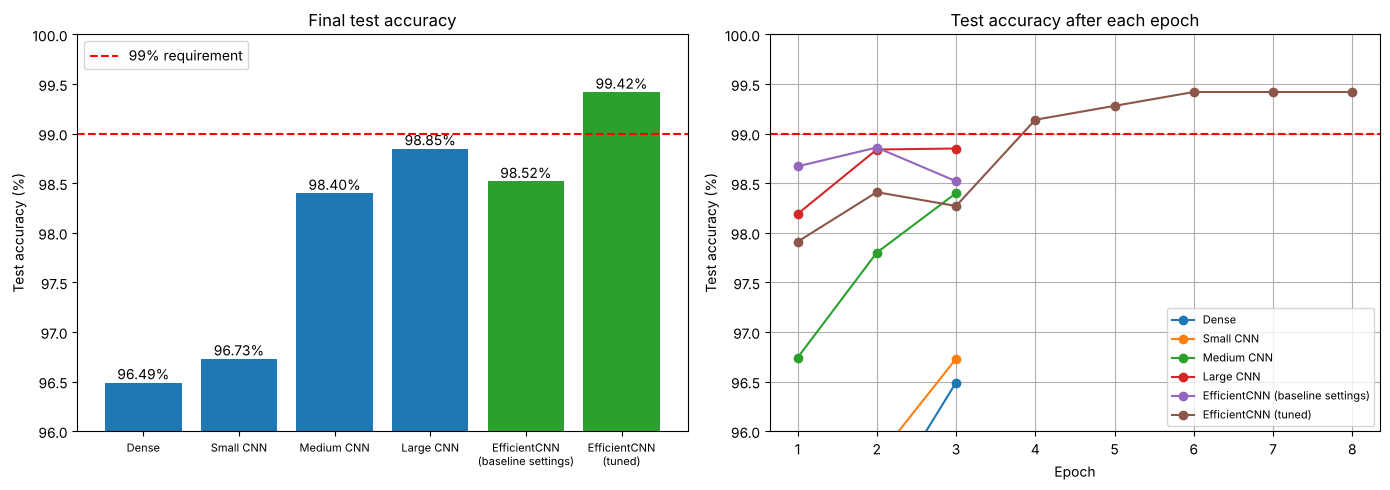

In [13]:
# NEW
colors = ["tab:green" if "EfficientCNN" in m else "tab:blue" for m in df["Model"]]
short_names = [m.replace("EfficientCNN ", "EfficientCNN\n") for m in df["Model"]]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

bars = ax[0].bar(short_names, df["Accuracy"] * 100, color=colors)
ax[0].bar_label(bars, fmt="%.2f%%")
ax[0].axhline(99, color="red", linestyle="--", label="99% requirement")
ax[0].set_ylim(96, 100)
ax[0].set_ylabel("Test accuracy (%)")
ax[0].set_title("Final test accuracy")
ax[0].tick_params(axis="x", labelsize=8)
ax[0].legend(loc="upper left")

for name, history in histories.items():
    ax[1].plot(range(1, len(history) + 1), [a * 100 for a in history], marker="o", label=name)
ax[1].axhline(99, color="red", linestyle="--")
ax[1].set_ylim(96, 100)
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Test accuracy (%)")
ax[1].set_title("Test accuracy after each epoch")
ax[1].grid(True)
ax[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Parameter graph

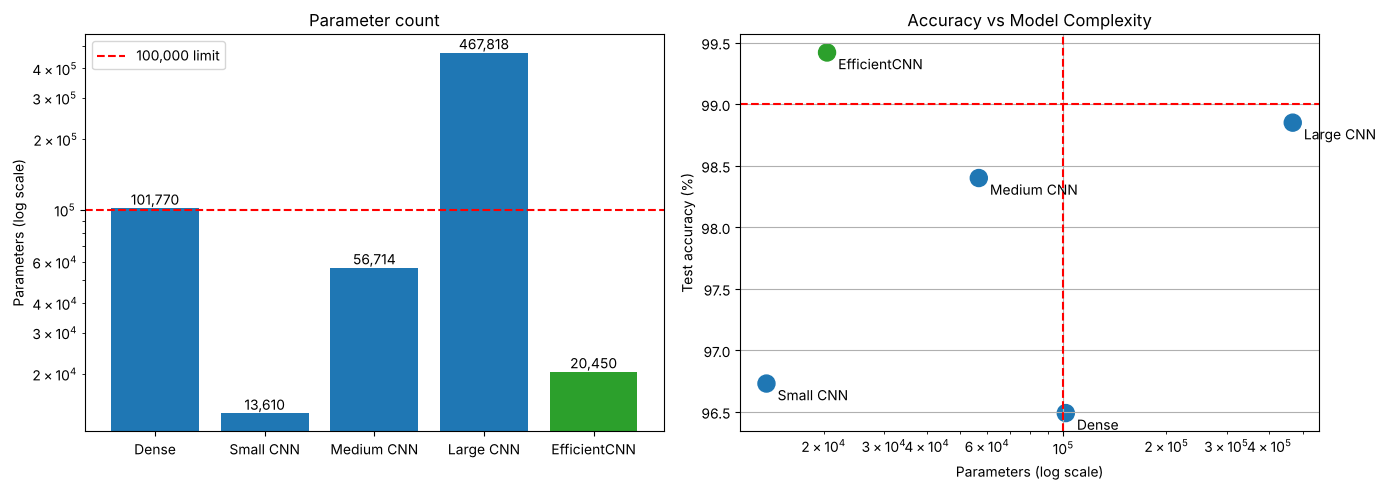

In [14]:
# CHANGED: one bar per model on a log scale, with the 100,000 limit drawn in
plot_df = df[df["Model"] != "EfficientCNN (baseline settings)"]   # same model as the tuned run
colors = ["tab:green" if "EfficientCNN" in m else "tab:blue" for m in plot_df["Model"]]
names = [m.replace(" (tuned)", "") for m in plot_df["Model"]]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

bars = ax[0].bar(names, plot_df["Parameters"], color=colors)
ax[0].bar_label(bars, labels=[f"{p:,}" for p in plot_df["Parameters"]])
ax[0].axhline(100_000, color="red", linestyle="--", label="100,000 limit")
ax[0].set_yscale("log")
ax[0].set_ylabel("Parameters (log scale)")
ax[0].set_title("Parameter count")
ax[0].legend()

ax[1].scatter(plot_df["Parameters"], plot_df["Accuracy"] * 100, s=150, c=colors)
for name, (_, row) in zip(names, plot_df.iterrows()):
    ax[1].annotate(name, (row["Parameters"], row["Accuracy"] * 100),
                   textcoords="offset points", xytext=(8, -12))
ax[1].axhline(99, color="red", linestyle="--")
ax[1].axvline(100_000, color="red", linestyle="--")
ax[1].set_xscale("log")
ax[1].set_xlabel("Parameters (log scale)")
ax[1].set_ylabel("Test accuracy (%)")
ax[1].set_title("Accuracy vs Model Complexity")
ax[1].grid(True)

plt.tight_layout()
plt.show()

## Training time

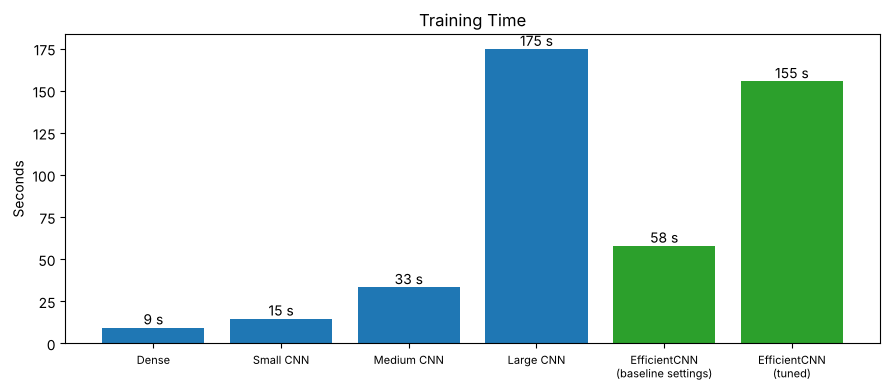

In [15]:
plt.figure(figsize=(9, 4))
bars = plt.bar(short_names, df["Train Time (s)"], color=["tab:green" if "EfficientCNN" in m else "tab:blue" for m in df["Model"]])
plt.bar_label(bars, fmt="%.0f s")
plt.ylabel("Seconds")
plt.title("Training Time")
plt.xticks(fontsize=8)
plt.tight_layout()
plt.show()

## Layer-by-layer summary of the new CNN

In [16]:
%pip install torchinfo
from torchinfo import summary
summary(EfficientCNN(), input_size=(1,1,28,28))

Layer (type:depth-idx)                   Output Shape              Param #
EfficientCNN                             [1, 10]                   --
├─Sequential: 1-1                        [1, 32, 3, 3]             --
│    └─Conv2d: 2-1                       [1, 8, 28, 28]            72
│    └─BatchNorm2d: 2-2                  [1, 8, 28, 28]            16
│    └─ReLU: 2-3                         [1, 8, 28, 28]            --
│    └─Conv2d: 2-4                       [1, 16, 28, 28]           1,152
│    └─BatchNorm2d: 2-5                  [1, 16, 28, 28]           32
│    └─ReLU: 2-6                         [1, 16, 28, 28]           --
│    └─MaxPool2d: 2-7                    [1, 16, 14, 14]           --
│    └─Conv2d: 2-8                       [1, 16, 14, 14]           2,304
│    └─BatchNorm2d: 2-9                  [1, 16, 14, 14]           32
│    └─ReLU: 2-10                        [1, 16, 14, 14]           --
│    └─Conv2d: 2-11                      [1, 32, 14, 14]           4,608
│    └

## Engineering justification

### Goal and result

The task was to design a CNN that reaches at least 99% test accuracy on MNIST with no more than 100,000 parameters. `EfficientCNN` reaches **99.42%** with **20,450 parameters**, which is about one fifth of the parameter budget. None of the four baseline models meets both constraints as provided: the Large CNN comes closest on accuracy (98.85%) but uses 467,818 parameters, and the Medium CNN fits the budget (56,714) but stops at 98.40%.

### Where the baseline parameters go

Before designing anything, I looked at where the baselines spend their parameters. In the Large CNN, the first linear layer (`64*7*7 -> 128`) holds 401,536 of the 467,818 parameters, about 86%. In the Medium CNN, the first linear layer (`32*5*5 -> 64`) holds 51,264 of 56,714, about 90%. The convolutions, which do the actual feature extraction, are cheap by comparison. The Dense network makes the same point from the other direction: 101,770 parameters with no convolutions gives the lowest accuracy in the table.

So the design rule was: spend parameters on convolutions, and make the classifier as small as possible.

### Design decisions

**1. Five 3x3 convolutions, widths 8, 16, 16, 32, 32.** Stacked 3x3 convolutions see a larger region of the image with each layer while staying cheap, since a 3x3 layer costs only `9 * in * out` weights. Widths grow as the image shrinks, so the expensive wide layers run on small feature maps. All five convolutions together cost 17,352 parameters.

**2. Padding of 1 on every convolution.** The baseline Small and Medium CNNs use no padding, so every convolution trims the border. Padding keeps the size at 28, 14, and 7 through the three stages, so only the pooling layers shrink the image and no edge information is lost early.

**3. Batch normalization after every convolution.** This adds only 208 parameters. It keeps activations in a stable range, which let me use a higher learning rate. The convolutions use `bias=False` because batch norm has its own shift term, so a bias would be redundant.

**4. A third pooling step, then one linear layer.** Pooling a third time reduces the feature maps to 3x3, so the flattened vector is `32*3*3 = 288` values and the classifier is a single `288 -> 10` layer with 2,890 parameters. There is no hidden dense layer. This is the decision that saves the most: it replaces the layer that costs the Large CNN 401,536 parameters.

**5. One-cycle learning rate schedule, 8 epochs.** The learning rate ramps up to 0.003 and then decays toward zero. The ramp-up moves quickly through the early part of training, and the decay lets the weights settle at the end instead of bouncing around.

### What I tried that did not work

I compared design options on a 5,000-image validation split held out from the training set. Those runs are not in this notebook, to keep its runtime down.

- **Global average pooling instead of flattening.** This is the usual trick for a tiny classifier, and it got the model down to 8,610 to 33,338 parameters. But validation accuracy after 5 epochs was only about 96% to 98.6%. Averaging each feature map to one number throws away where a feature is, and with only two pooling stages that hurt.
- **No batch norm.** With the same layers, removing batch norm lowered validation accuracy in every one of the first three epochs (for example 97.3% vs 98.5% after epoch 1).
- **A hidden dense layer of 48 units.** This raised the count to 92,266 parameters and was no better than the version with no hidden layer (both peaked at about 99.1% over 4 epochs).
- **Wider convolutions (16, 16, 32, 32, 32; 28,634 parameters).** With the tuned schedule this reached 99.32% validation accuracy against 99.30% for the 20,450-parameter version. That difference is noise, so I kept the smaller model.

### Architecture versus training settings

The table includes `EfficientCNN` trained with the baseline settings (3 epochs, constant learning rate) so the two effects can be separated. With those settings it reaches 98.52%. That is above the Medium CNN (98.40%) with 36% of its parameters, and below the Large CNN (98.85%) with 4% of its parameters. It does not reach 99%.

So the architecture alone gets close, and the training schedule is what carries it over the line. The accuracy graph shows this: the tuned run crosses 99% at epoch 4 and levels off at 99.42% from epoch 6 on.

### Trade-offs and limits

- **Parameters are not the same as compute.** `EfficientCNN` takes about 19 seconds per epoch on CPU, against about 11 for the Medium CNN, even though it has fewer parameters. Its convolutions run at the full 28x28 resolution and batch norm adds work. It is still about three times faster per epoch than the Large CNN (about 58 seconds).
- **The baselines were not retrained with the tuned settings.** The Medium and Large CNNs would likely improve with 8 epochs and a schedule too. The fair architecture comparison is the 3-epoch rows; the 99.42% row shows the constraint is met.
- **One seed.** Each number comes from a single run with seed 0. Results will shift by a tenth of a percent or so between runs. The margin above 99% is 0.42 points, which is larger than that.
- **Reported accuracy is from the final epoch,** not the best epoch, so the test set was not used to pick a stopping point.

### Conclusion

For mobile or embedded use, `EfficientCNN` is the strongest option in the table: 0.078 MB of weights, about 2.8 million multiply-adds per image, and the highest accuracy. The main lesson is that on an image task the dense layers are where a parameter budget is wasted. Shrinking the feature maps before flattening, and keeping the capacity in the convolutions, gave a model 23 times smaller than the Large CNN that is also more accurate.